
# Autonomous state-dependent switched network systems with repeated graph switching

We simulate autonomous switched network systems
$$
\dot z_i = f_i(z_i) + \gamma \sum_{j\neq i} A_{ij}(z)\,(z_j-z_i),
\qquad
A_{ij}(z)=\mathbf 1_{\{\|z_i-z_j\|\le \varepsilon\}},
$$
with $N=3$ or $4$ nodes and $z_i\in\mathbb R^2$.

The emphasis is on **autonomous nonlinear node dynamics** that can still generate
**multiple threshold crossings** and hence repeated graph switching.
No explicit time dependence or external forcing is used.


In [1]:

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from itertools import combinations

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 10


In [2]:

# ---------- Core simulator ----------

def pair_indices(N):
    return list(combinations(range(N), 2))

def adjacency_from_state(X, eps):
    N = X.shape[0]
    A = np.zeros((N, N), dtype=int)
    for i in range(N):
        for j in range(i+1, N):
            if np.linalg.norm(X[i] - X[j]) <= eps:
                A[i, j] = 1
                A[j, i] = 1
    return A

def diffusive_coupling(X, A, gamma):
    N, d = X.shape
    out = np.zeros_like(X, dtype=float)
    for i in range(N):
        for j in range(N):
            if i != j and A[i, j] == 1:
                out[i] += gamma * (X[j] - X[i])
    return out

def simulate_switched_network(f_list, X0, T=60.0, dt=0.02, eps=1.2, gamma=0.15):
    X0 = np.array(X0, dtype=float)
    N, d = X0.shape
    steps = int(round(T / dt))
    t = np.linspace(0.0, T, steps + 1)

    X = np.zeros((steps + 1, N, d))
    A_hist = np.zeros((steps + 1, N, N), dtype=int)
    X[0] = X0
    A_hist[0] = adjacency_from_state(X[0], eps)

    def F(state):
        A = adjacency_from_state(state, eps)
        val = np.zeros_like(state, dtype=float)
        for i, f in enumerate(f_list):
            val[i] = f(state[i])
        val += diffusive_coupling(state, A, gamma)
        return val

    for k in range(steps):
        s = X[k]
        k1 = F(s)
        k2 = F(s + 0.5 * dt * k1)
        k3 = F(s + 0.5 * dt * k2)
        k4 = F(s + dt * k3)
        X[k+1] = s + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        A_hist[k+1] = adjacency_from_state(X[k+1], eps)

    return t, X, A_hist

def pairwise_distance_history(X):
    pairs = pair_indices(X.shape[1])
    D = {}
    for i, j in pairs:
        D[(i, j)] = np.linalg.norm(X[:, i, :] - X[:, j, :], axis=1)
    return D

def switch_count(A_hist):
    pairs = pair_indices(A_hist.shape[1])
    total = 0
    per_pair = {}
    for i, j in pairs:
        s = A_hist[:, i, j]
        c = int(np.sum(s[1:] != s[:-1]))
        per_pair[(i, j)] = c
        total += c
    return total, per_pair

def active_edge_count(A_hist):
    return 0.5 * np.sum(A_hist, axis=(1,2))

def edge_signal_matrix(A_hist):
    N = A_hist.shape[1]
    pairs = pair_indices(N)
    S = np.zeros((len(pairs), A_hist.shape[0]), dtype=int)
    labels = []
    for k, (i, j) in enumerate(pairs):
        S[k] = A_hist[:, i, j]
        labels.append(f"{i}-{j}")
    return S, labels


In [3]:

# ---------- Autonomous nonlinear node families ----------

def stuart_landau(mu=1.0, omega=1.0):
    # stable limit cycle at r = sqrt(mu) for mu > 0
    def f(z):
        x, y = z
        r2 = x*x + y*y
        return np.array([
            mu*x - omega*y - r2*x,
            omega*x + mu*y - r2*y
        ])
    return f

def radial_poly(omega=1.0, roots=(0.7, 1.3), stable_pattern="one_cycle"):
    # x' = alpha(r^2) x - omega y,  y' = omega x + alpha(r^2) y
    # alpha chosen so that selected radii become attracting invariant circles
    roots = tuple(roots)
    if stable_pattern == "one_cycle":
        # one stable cycle at roots[0]
        r1 = roots[0]
        def alpha(s):
            return (r1**2 - s)
    elif stable_pattern == "two_cycles":
        r1, r2 = roots
        rm = 0.5*(r1 + r2)
        sm = rm**2
        # alpha(s)=-(s-r1^2)(s-r2^2)(s-sm) gives stable at r1,r2 and unstable at rm
        def alpha(s):
            return -(s-r1**2)*(s-r2**2)*(s-sm)
    elif stable_pattern == "three_cycles":
        r1, r2, r3 = roots
        rm1 = 0.5*(r1 + r2)
        rm2 = 0.5*(r2 + r3)
        sm1 = rm1**2
        sm2 = rm2**2
        def alpha(s):
            return (r1**2-s)*(s-rm1**2)*(r2**2-s)*(s-rm2**2)*(r3**2-s)
    else:
        raise ValueError("Unknown stable_pattern")

    def f(z):
        x, y = z
        s = x*x + y*y
        a = alpha(s)
        return np.array([a*x - omega*y, omega*x + a*y])
    return f

def subcritical_hopf(mu=-0.05, omega=1.0, beta=1.4):
    # r' = r (mu + r^2 - beta r^4), can exhibit stable equilibrium and stable cycle
    def f(z):
        x, y = z
        r2 = x*x + y*y
        a = mu + r2 - beta*(r2**2)
        return np.array([a*x - omega*y, omega*x + a*y])
    return f

def van_der_pol(mu=1.5):
    def f(z):
        x, y = z
        return np.array([y, mu*(1-x*x)*y - x])
    return f

def fitzhugh_nagumo(a=0.7, b=0.8, tau=12.5, I=0.5):
    def f(z):
        v, w = z
        return np.array([
            v - v**3/3 - w + I,
            (v + a - b*w)/tau
        ])
    return f

def selkov(alpha=0.08, beta=0.6):
    # simple glycolytic oscillator regime for some parameters
    def f(z):
        x, y = z
        dx = -x + alpha*y + x*x*y
        dy = beta - alpha*y - x*x*y
        return np.array([dx, dy])
    return f

def toggle_osc_surrogate(a=2.6, b=2.2, k=1.0):
    # autonomous planar nonlinear system with two attracting regions and rotational cross-coupling
    def f(z):
        x, y = z
        return np.array([
            a*x - x**3 - k*y,
            b*y - y**3 + k*x
        ])
    return f


In [4]:

# ---------- Plotting ----------

def plot_example(name, t, X, A_hist, eps):
    N = X.shape[1]
    D = pairwise_distance_history(X)
    edge_ct = active_edge_count(A_hist)
    S, labels = edge_signal_matrix(A_hist)
    total_switches, per_pair = switch_count(A_hist)

    fig = plt.figure(figsize=(14, 10))

    ax1 = plt.subplot(2, 3, 1)
    for i in range(N):
        ax1.plot(X[:, i, 0], X[:, i, 1], label=f"node {i}")
        ax1.plot(X[0, i, 0], X[0, i, 1], "o", ms=4)
    ax1.set_title(f"{name}: state-space trajectories")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.legend(loc="best", fontsize=8)

    ax2 = plt.subplot(2, 3, 2)
    for i in range(N):
        ax2.plot(t, X[:, i, 0], label=f"node {i}")
    ax2.set_title("first component vs time")
    ax2.set_xlabel("t")

    ax3 = plt.subplot(2, 3, 3)
    ax3.plot(t, edge_ct)
    ax3.set_title(f"active edges vs time | total switches={total_switches}")
    ax3.set_xlabel("t")
    ax3.set_ylabel("# active edges")

    ax4 = plt.subplot(2, 3, 4)
    for (i, j), d in D.items():
        ax4.plot(t, d, label=f"d{i}{j}")
    ax4.axhline(eps, ls="--", color="k", lw=1)
    ax4.set_title("pairwise distances")
    ax4.set_xlabel("t")
    ax4.legend(loc="best", fontsize=8)

    ax5 = plt.subplot(2, 3, 5)
    ax5.imshow(S, aspect="auto", interpolation="nearest", extent=[t[0], t[-1], len(labels)-0.5, -0.5])
    ax5.set_yticks(np.arange(len(labels)))
    ax5.set_yticklabels(labels)
    ax5.set_title("edge signals A_ij(t)")
    ax5.set_xlabel("t")

    ax6 = plt.subplot(2, 3, 6)
    rows = []
    for k, lab in enumerate(labels):
        rows.append((lab, per_pair[tuple(map(int, lab.split("-")))]))
    txt = "\n".join([f"{lab}: {cnt}" for lab, cnt in rows])
    ax6.axis("off")
    ax6.text(0.02, 0.98, txt, va="top", family="monospace")
    ax6.set_title("switches per pair")

    plt.tight_layout()
    plt.show()


In [5]:

# ---------- Example library ----------
# The point here is computational exploration, so slight parameter heterogeneity is allowed.
# All systems are autonomous; no explicit time dependence is used.

examples = []

examples.append(dict(
    name="EX01_stuart_landau_3nodes_detuned",
    N=3, eps=1.55, gamma=0.10, T=60.0, dt=0.02,
    f_list=[
        stuart_landau(mu=1.0, omega=0.95),
        stuart_landau(mu=1.0, omega=1.05),
        stuart_landau(mu=1.0, omega=1.18),
    ],
    X0=np.array([[1.4, 0.0], [0.1, 1.2], [-1.1, -0.4]])
))

examples.append(dict(
    name="EX02_stuart_landau_4nodes_radius_mismatch",
    N=4, eps=1.35, gamma=0.09, T=65.0, dt=0.02,
    f_list=[
        stuart_landau(mu=0.7, omega=0.95),
        stuart_landau(mu=1.0, omega=1.00),
        stuart_landau(mu=1.3, omega=1.08),
        stuart_landau(mu=0.9, omega=1.16),
    ],
    X0=np.array([[1.2, 0.0], [0.1, 1.0], [-1.0, 0.2], [0.2, -1.1]])
))

examples.append(dict(
    name="EX03_radial_two_cycles_3nodes",
    N=3, eps=1.25, gamma=0.08, T=70.0, dt=0.02,
    f_list=[
        radial_poly(omega=0.92, roots=(0.75, 1.45), stable_pattern="two_cycles"),
        radial_poly(omega=1.04, roots=(0.75, 1.45), stable_pattern="two_cycles"),
        radial_poly(omega=1.18, roots=(0.75, 1.45), stable_pattern="two_cycles"),
    ],
    X0=np.array([[0.9, 0.0], [1.55, 0.1], [0.1, -0.85]])
))

examples.append(dict(
    name="EX04_radial_two_cycles_4nodes_mixed_basins",
    N=4, eps=1.15, gamma=0.07, T=70.0, dt=0.02,
    f_list=[
        radial_poly(omega=0.90, roots=(0.65, 1.55), stable_pattern="two_cycles"),
        radial_poly(omega=1.00, roots=(0.65, 1.55), stable_pattern="two_cycles"),
        radial_poly(omega=1.10, roots=(0.65, 1.55), stable_pattern="two_cycles"),
        radial_poly(omega=1.22, roots=(0.65, 1.55), stable_pattern="two_cycles"),
    ],
    X0=np.array([[0.75, 0.0], [1.65, 0.0], [0.0, 0.7], [-1.55, 0.0]])
))

examples.append(dict(
    name="EX05_subcritical_hopf_rest_cycle",
    N=4, eps=1.00, gamma=0.08, T=80.0, dt=0.02,
    f_list=[
        subcritical_hopf(mu=-0.05, omega=0.92, beta=1.35),
        subcritical_hopf(mu=-0.05, omega=1.00, beta=1.35),
        subcritical_hopf(mu=-0.05, omega=1.08, beta=1.35),
        subcritical_hopf(mu=-0.05, omega=1.18, beta=1.35),
    ],
    X0=np.array([[0.15, 0.0], [1.05, 0.0], [0.0, -1.0], [-0.2, 0.1]])
))

examples.append(dict(
    name="EX06_vanderpol_3nodes",
    N=3, eps=2.15, gamma=0.05, T=80.0, dt=0.02,
    f_list=[
        van_der_pol(mu=1.1),
        van_der_pol(mu=1.6),
        van_der_pol(mu=2.0),
    ],
    X0=np.array([[1.8, 0.0], [0.3, 1.6], [-1.5, 0.4]])
))

examples.append(dict(
    name="EX07_fitzhugh_nagumo_4nodes",
    N=4, eps=1.65, gamma=0.06, T=120.0, dt=0.03,
    f_list=[
        fitzhugh_nagumo(a=0.7, b=0.8, tau=12.5, I=0.52),
        fitzhugh_nagumo(a=0.7, b=0.8, tau=12.5, I=0.56),
        fitzhugh_nagumo(a=0.7, b=0.8, tau=12.5, I=0.60),
        fitzhugh_nagumo(a=0.7, b=0.8, tau=12.5, I=0.64),
    ],
    X0=np.array([[-1.1, -0.2], [0.7, 0.5], [1.2, -0.1], [0.0, 1.0]])
))

examples.append(dict(
    name="EX08_selkov_3nodes",
    N=3, eps=0.80, gamma=0.05, T=120.0, dt=0.02,
    f_list=[
        selkov(alpha=0.08, beta=0.55),
        selkov(alpha=0.08, beta=0.60),
        selkov(alpha=0.08, beta=0.65),
    ],
    X0=np.array([[0.7, 1.0], [1.2, 0.7], [0.9, 1.4]])
))

examples.append(dict(
    name="EX09_toggle_rotational_3nodes",
    N=3, eps=1.75, gamma=0.08, T=70.0, dt=0.02,
    f_list=[
        toggle_osc_surrogate(a=2.4, b=2.0, k=0.9),
        toggle_osc_surrogate(a=2.4, b=2.0, k=1.0),
        toggle_osc_surrogate(a=2.4, b=2.0, k=1.1),
    ],
    X0=np.array([[1.3, 0.4], [-1.1, 0.9], [0.7, -1.0]])
))


In [6]:

# Quick check of the example names
[p["name"] for p in examples]


['EX01_stuart_landau_3nodes_detuned',
 'EX02_stuart_landau_4nodes_radius_mismatch',
 'EX03_radial_two_cycles_3nodes',
 'EX04_radial_two_cycles_4nodes_mixed_basins',
 'EX05_subcritical_hopf_rest_cycle',
 'EX06_vanderpol_3nodes',
 'EX07_fitzhugh_nagumo_4nodes',
 'EX08_selkov_3nodes',
 'EX09_toggle_rotational_3nodes']

In [7]:

# ---------- Run every example and summarize switching ----------
results = []
cache = {}

for ex in examples:
    t, X, A_hist = simulate_switched_network(
        ex["f_list"], ex["X0"],
        T=ex["T"], dt=ex["dt"], eps=ex["eps"], gamma=ex["gamma"]
    )
    total_switches, per_pair = switch_count(A_hist)
    cache[ex["name"]] = dict(t=t, X=X, A_hist=A_hist, total_switches=total_switches, per_pair=per_pair)
    results.append({
        "name": ex["name"],
        "N": ex["N"],
        "eps": ex["eps"],
        "gamma": ex["gamma"],
        "total_switches": total_switches,
        "active_edge_min": float(np.min(active_edge_count(A_hist))),
        "active_edge_max": float(np.max(active_edge_count(A_hist))),
    })

summary_df = pd.DataFrame(results).sort_values(["total_switches", "name"], ascending=[False, True]).reset_index(drop=True)
summary_df


,name,N,eps,gamma,total_switches,active_edge_min,active_edge_max
0,EX06_vanderpol_3nodes,3,2.15,0.05,135,0.0,3.0
1,EX08_selkov_3nodes,3,0.80,0.05,58,1.0,3.0
2,EX09_toggle_rotational_3nodes,3,1.75,0.08,36,0.0,3.0
3,EX04_radial_two_cycles_4nodes_mixed_basins,4,1.15,0.07,18,1.0,4.0
4,EX07_fitzhugh_nagumo_4nodes,4,1.65,0.06,12,2.0,6.0
5,EX02_stuart_landau_4nodes_radius_mismatch,4,1.35,0.09,6,0.0,6.0
6,EX05_subcritical_hopf_rest_cycle,4,1.00,0.08,4,2.0,6.0
7,EX01_stuart_landau_3nodes_detuned,3,1.55,0.10,3,0.0,3.0
8,EX03_radial_two_cycles_3nodes,3,1.25,0.08,1,2.0,3.0



## Interpretation

A useful necessary indicator of persistent switching is that some pair satisfies
\[
\liminf_t d_{ij}(t) < 
arepsilon < \limsup_t d_{ij}(t),
\]
so the threshold is crossed repeatedly.  
The examples with larger `total_switches` are the most promising for autonomous switched-network exploration.


In [8]:

# ---------- Plot the top examples by switching count ----------
top_names = list(summary_df.head(min(6, len(summary_df)))["name"])
top_names


['EX06_vanderpol_3nodes',
 'EX08_selkov_3nodes',
 'EX09_toggle_rotational_3nodes',
 'EX04_radial_two_cycles_4nodes_mixed_basins',
 'EX07_fitzhugh_nagumo_4nodes',
 'EX02_stuart_landau_4nodes_radius_mismatch']

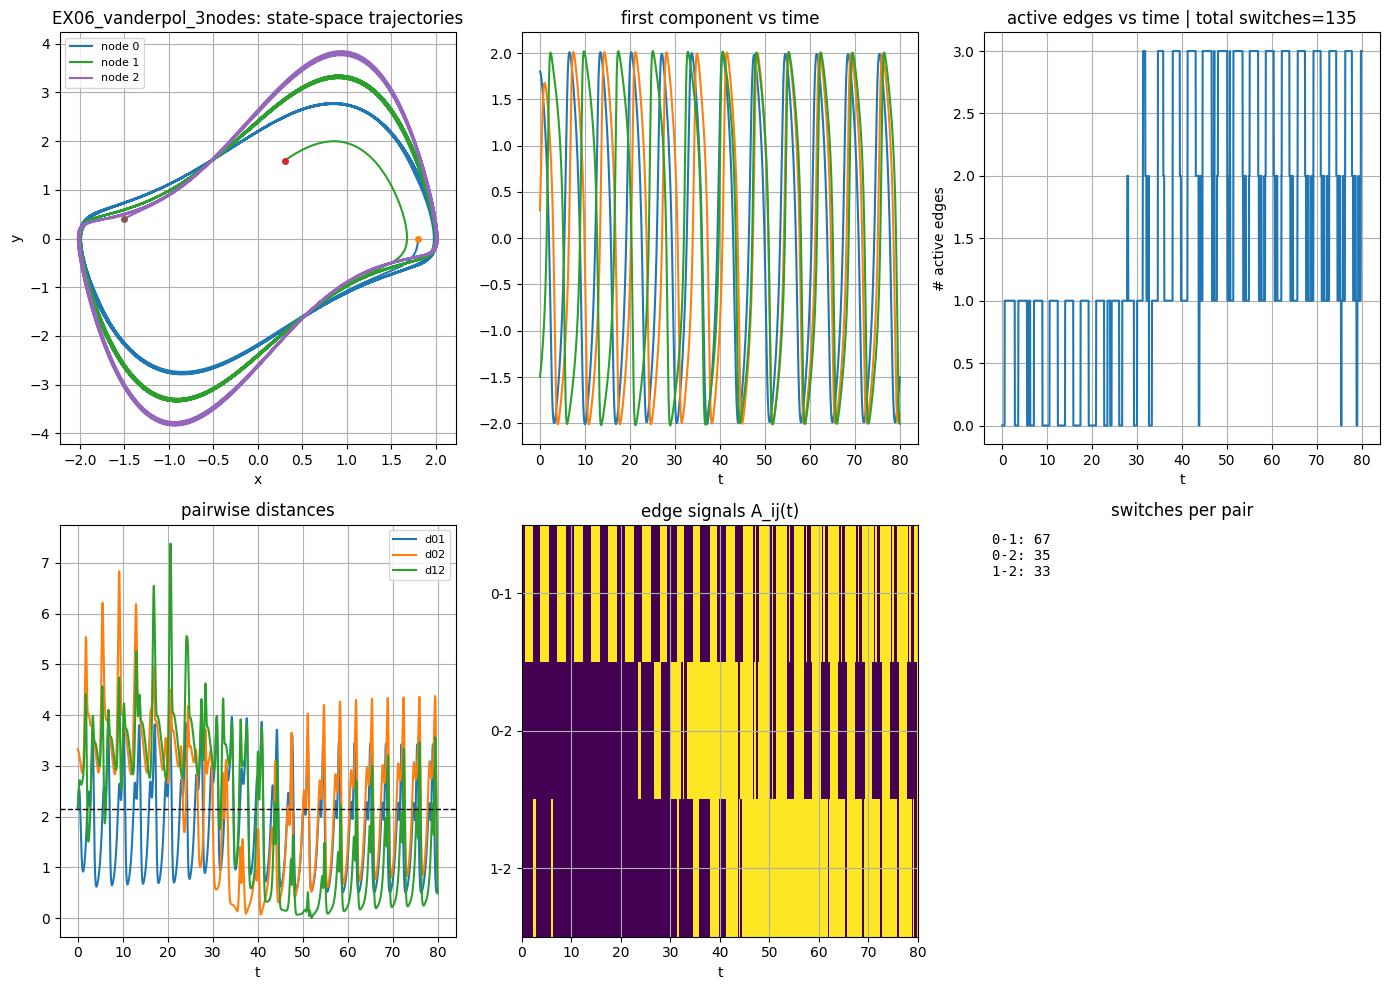

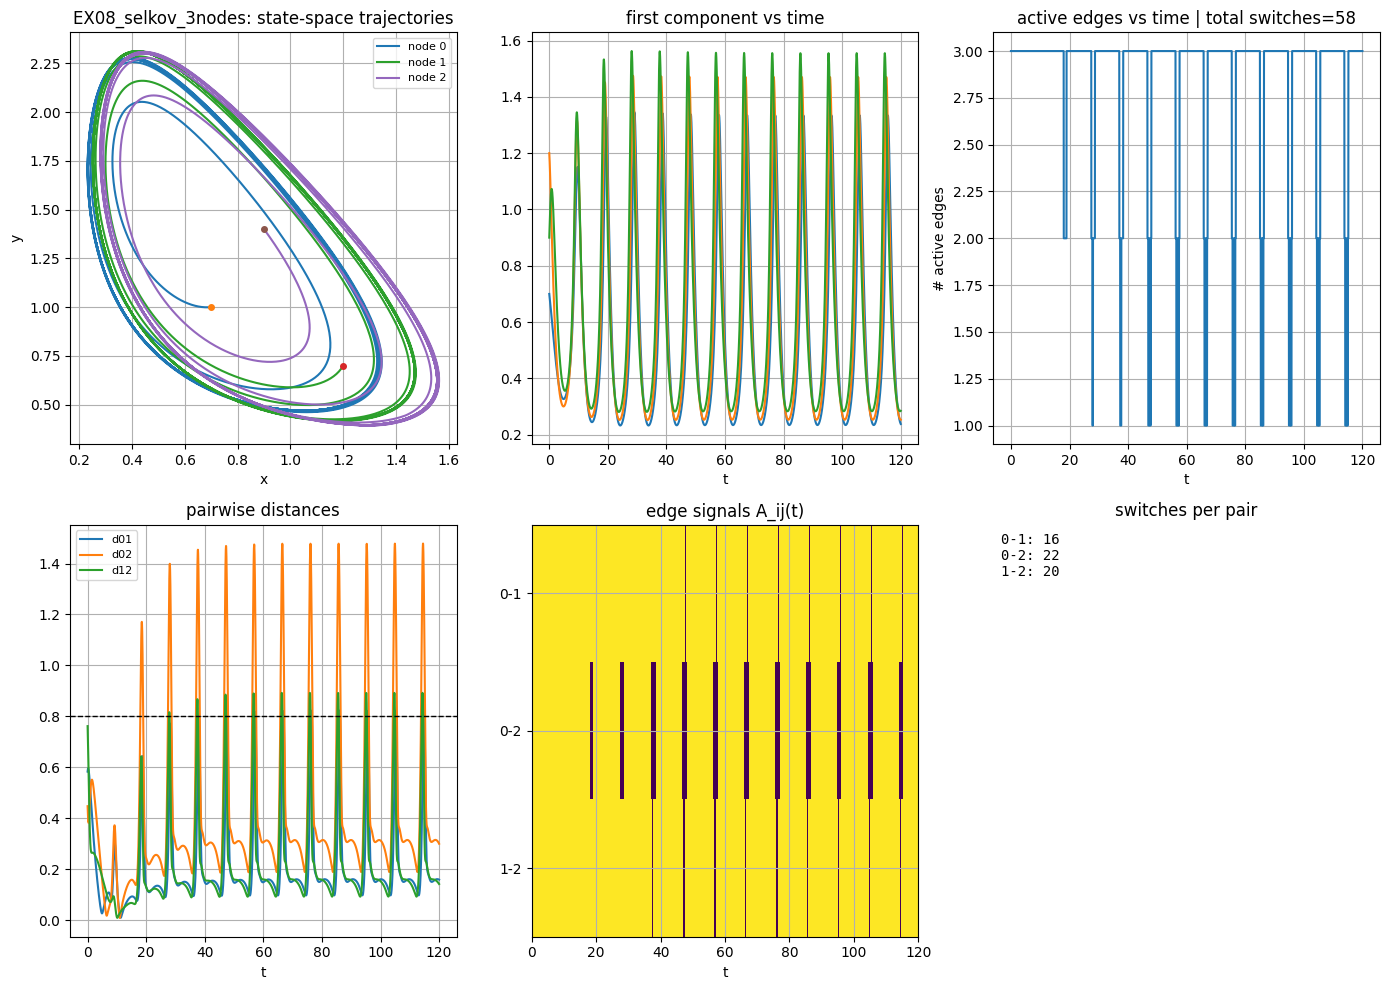

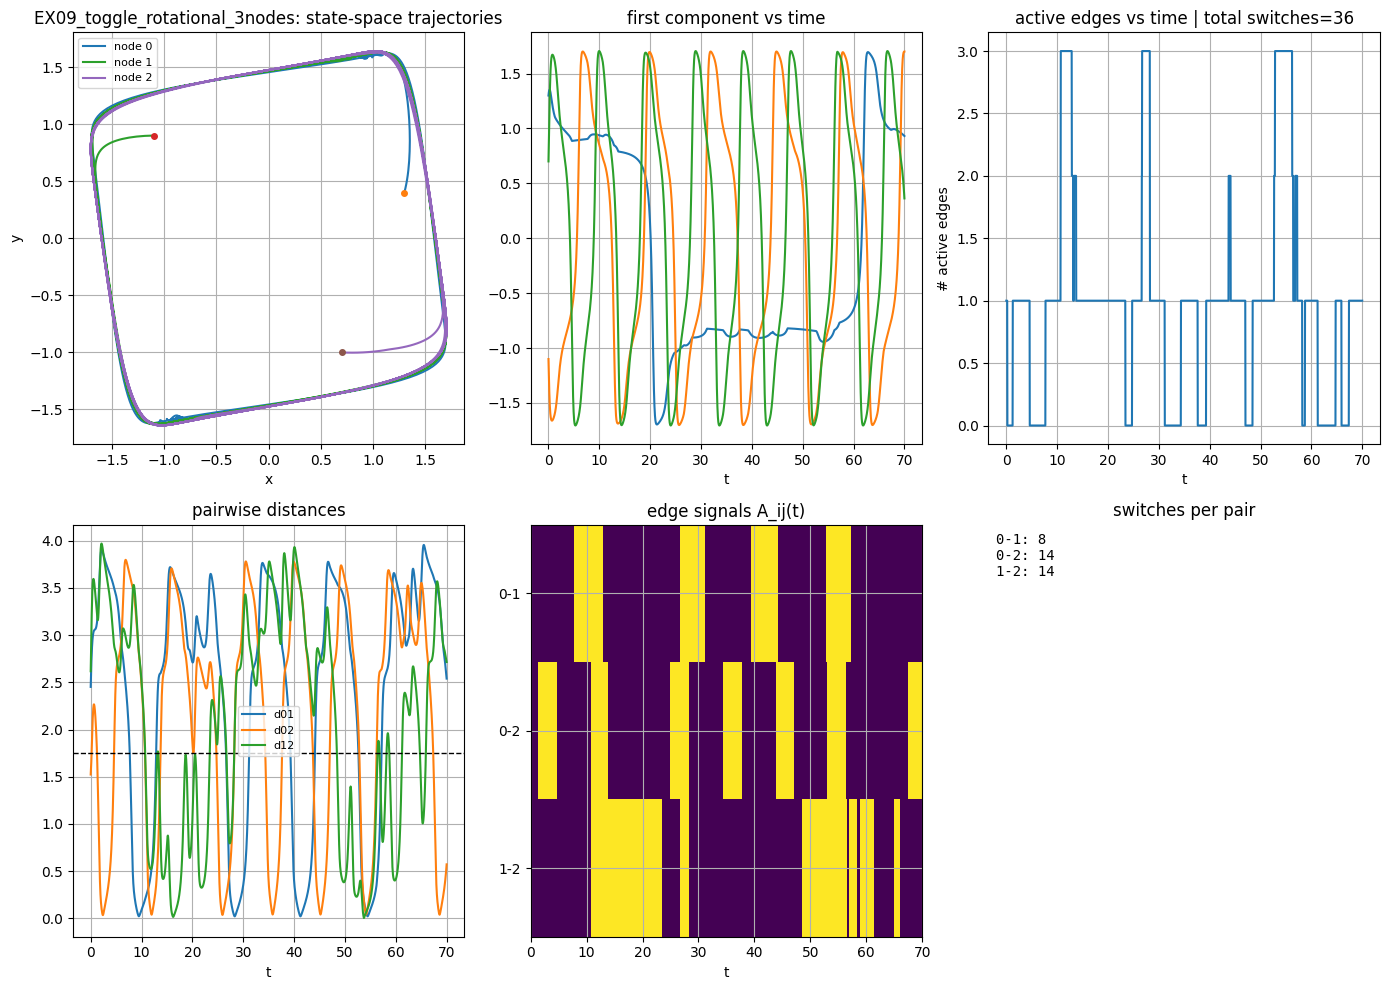

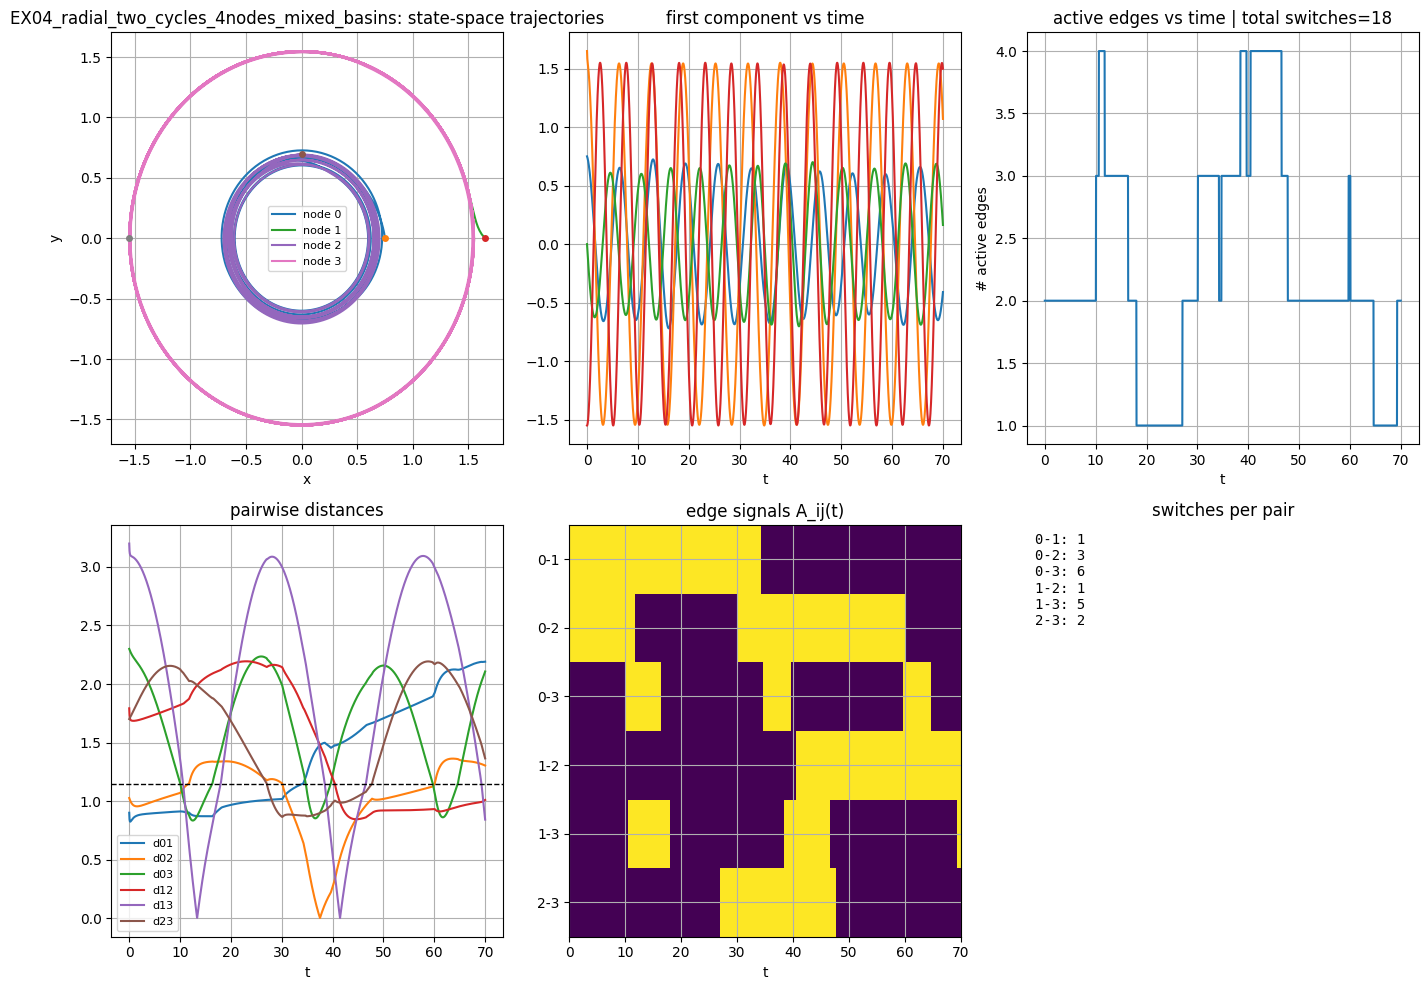

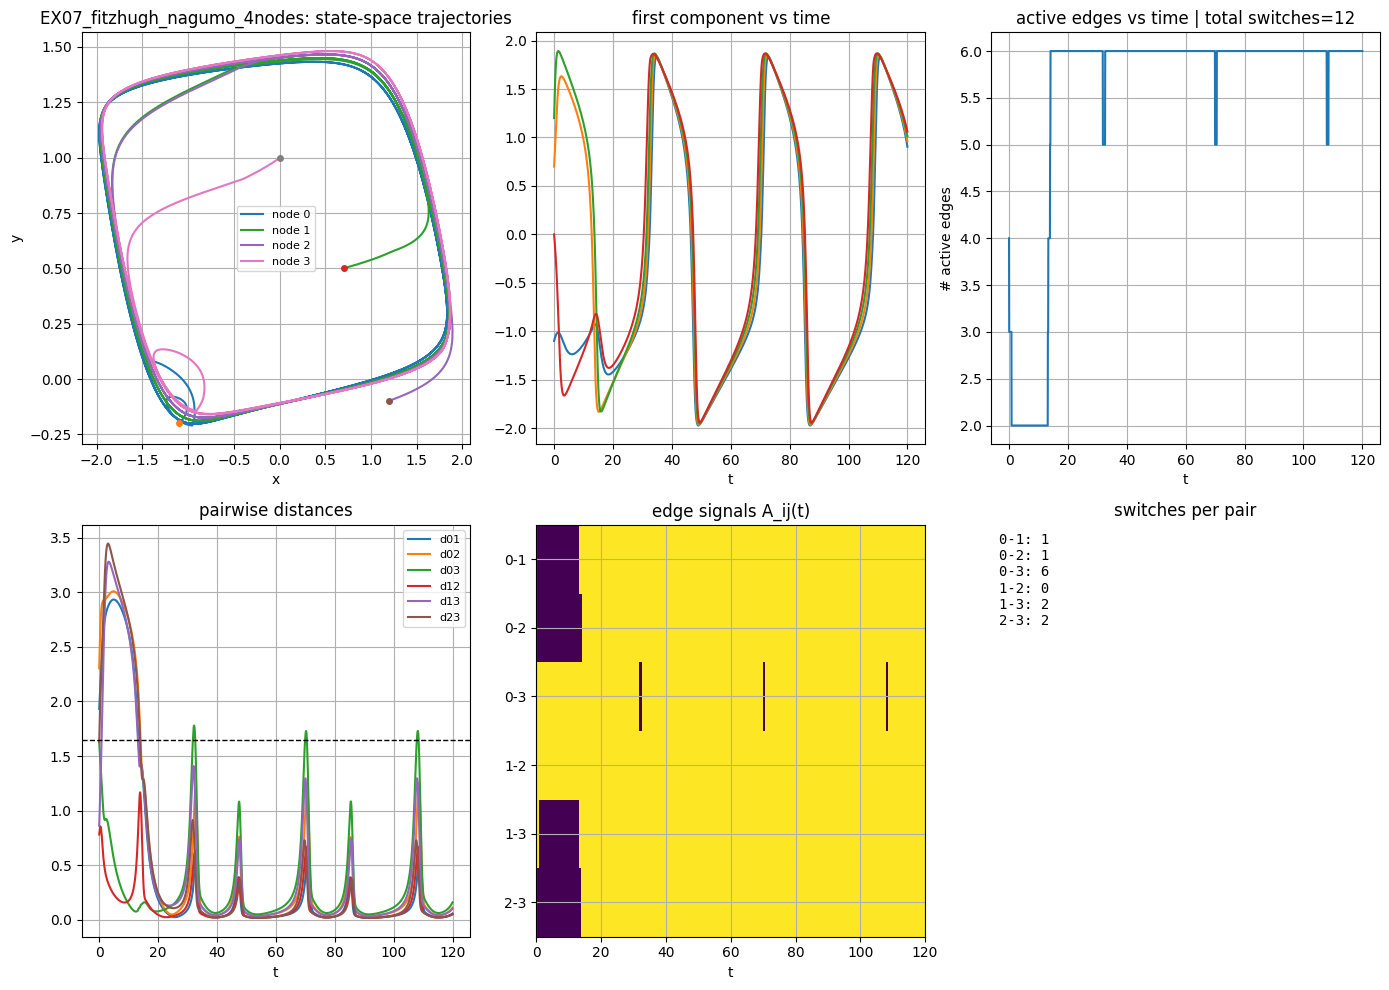

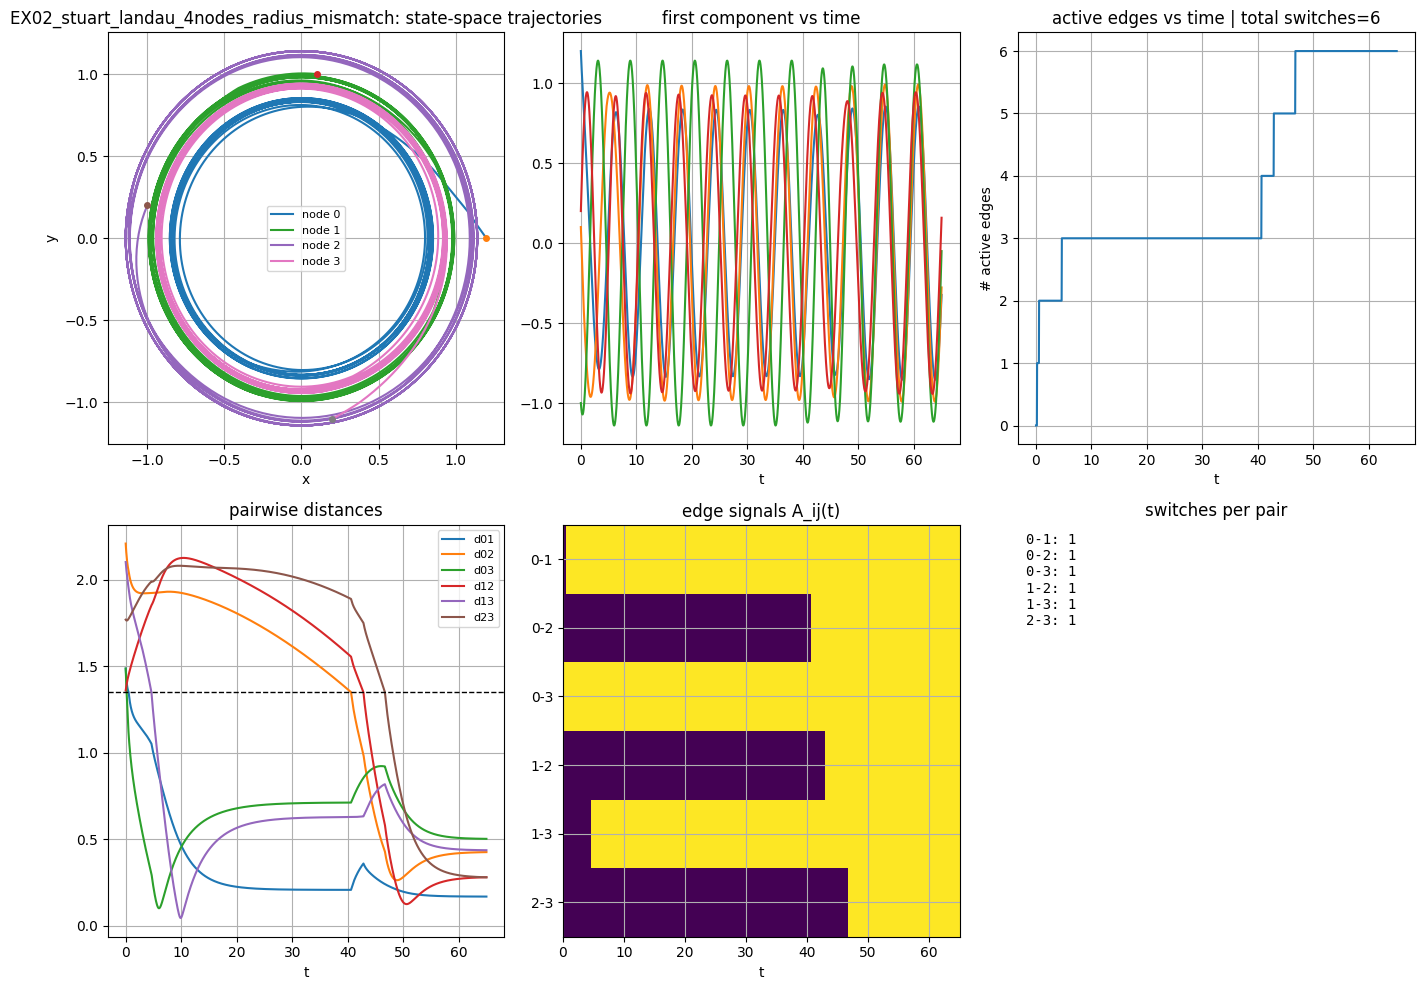

In [9]:

for name in top_names:
    ex = next(p for p in examples if p["name"] == name)
    dat = cache[name]
    plot_example(name, dat["t"], dat["X"], dat["A_hist"], ex["eps"])


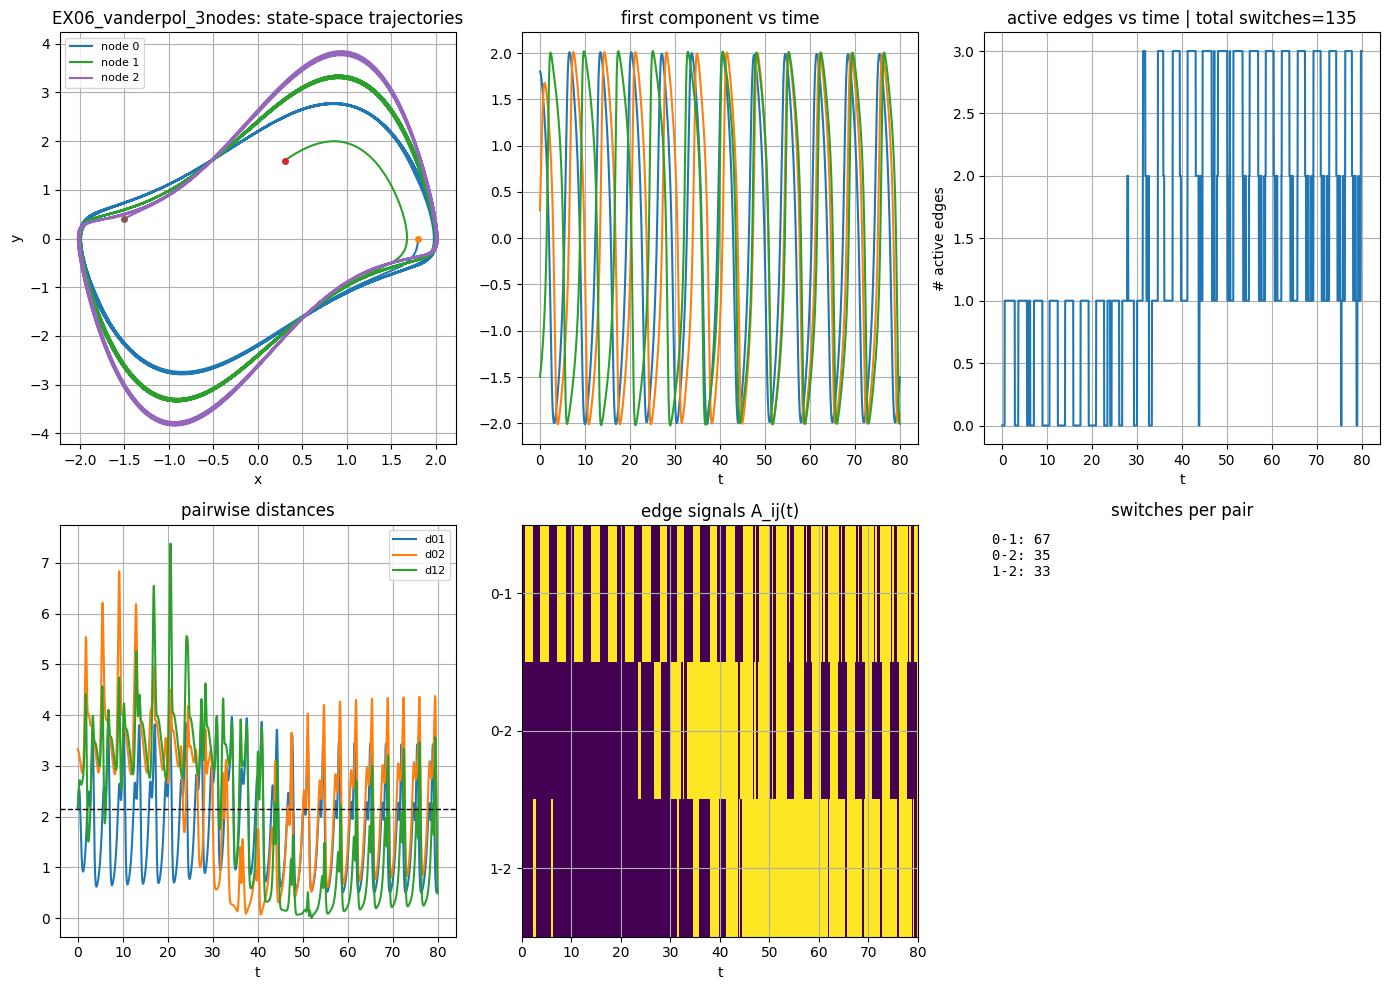

In [10]:

# ---------- Manual explorer ----------
# Set one of the names below if you want to inspect a different example.

example_name = summary_df.iloc[0]["name"]
ex = next(p for p in examples if p["name"] == example_name)
dat = cache[example_name]
plot_example(example_name, dat["t"], dat["X"], dat["A_hist"], ex["eps"])



## Suggested shortlist for later theorem + computation work

For your autonomous Conley/Morse-graph-oriented direction, the most promising families are usually:

- detuned **Stuart–Landau / Hopf normal form** examples,
- **subcritical Hopf** with rest-cycle coexistence,
- **radial multicycle** oscillators with more than one invariant radius,
- autonomous excitable oscillators such as **Van der Pol** and **FitzHugh–Nagumo**,

because they are autonomous, low-dimensional, and their invariant sets are interpretable:
equilibria, limit cycles, and coexistence of several attractors.

The next natural step is to keep only the 4–5 best examples and tune
$\varepsilon$, $\gamma$, and initial conditions so that switching remains visible but the dynamics stay clean enough for later topological computation.
